In [ ]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/chNN/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Example: Peng-Robinson isotherms for nitrogen (package version)

> **Package version.** This notebook uses the shared `thermo` package (`PengRobinson`) instead of re-deriving the Peng–Robinson EOS inline. Compare with the self-contained companion [`PR_isotherms_N2_example.ipynb`](PR_isotherms_N2_example.ipynb), which builds every routine from scratch.
>
> Critical constants ($T_c$, $P_c$), the acentric factor $\omega$, and the ideal-gas $C_p$ coefficients are read from `code/data/pure_property.csv` via `PengRobinson.from_database`, so the numbers can differ slightly from the hand-entered SIS Table 6.6-1 values in the self-contained notebook.

## The Peng-Robinson EOS, from the `thermo` package

The generalized Peng-Robinson equation of state (SIS Eq. 6.4-2) is

$$ P = \frac{RT}{\underline{V}-b} - \frac{a(T)}{\underline{V}(\underline{V}+b) + b(\underline{V}-b)} \tag{Eq. 6.4-2}$$

with $b = 0.07780\,RT_c/P_c$ (Eq. 6.7-2), $a(T)=0.45724\,R^2T_c^2/P_c\,\alpha(T)$ (Eq. 6.7-1), $\sqrt{\alpha}=1+\kappa(1-\sqrt{T/T_c})$ (Eq. 6.7-3), and $\kappa = 0.37464 + 1.54226\omega - 0.26992\omega^2$ (Eq. 6.7-4).

All of this — building the cubic, taking its compressibility roots (SIS Table 6.4-3), and the departure functions below — is implemented in `thermo.PengRobinson`. The self-contained companion notebook codes each of these by hand; here we just call them.

Here we only need the *pressure explicit* form, `pr.pressure(V, T)`, evaluated along several isotherms.

In [1]:
import sys; sys.path.append("..")   # so `import thermo` works from the chapter folder
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants, optimize
from thermo import PengRobinson

R = constants.R

In [2]:
pr = PengRobinson.from_database('nitrogen')
print(f"{pr.name}: Tc={pr.Tc:.1f} K, Pc={pr.Pc/1e5:.2f} bar, omega={pr.omega:.3f}")

nitrogen: Tc=126.2 K, Pc=33.90 bar, omega=0.039


## Quick $P$-$\underline{V}$ plot

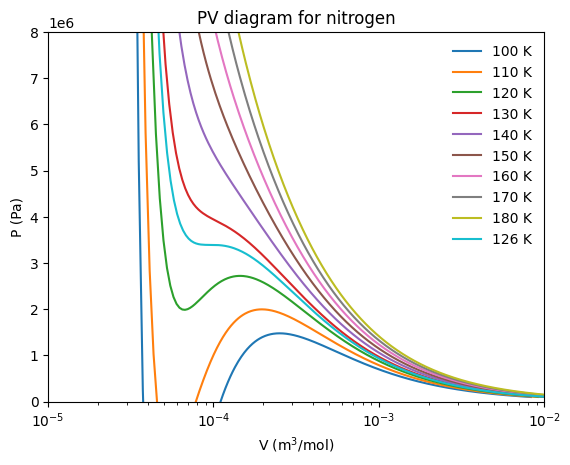

In [3]:
fig, ax = plt.subplots()
for T in list(range(100, 185, 10)) + [pr.Tc]:
    V_max = R*T/(100e3)
    V_min = R*T/(1000e3)*0.03
    V = np.linspace(V_min, V_max, 4000)
    ax.plot(V, pr.pressure(V, T), "-", label=f"{T:.0f} K")

ax.set_xscale("log")
ax.set_ylim([-1, 8e6]); ax.set_xlim([1e-5, 1e-2])
ax.set_xlabel("V (m$^3$/mol)"); ax.set_ylabel("P (Pa)")
ax.set_title("PV diagram for nitrogen")
ax.legend(frameon=True, fancybox=True, edgecolor='none'); plt.show()

## A prettier version with Seaborn

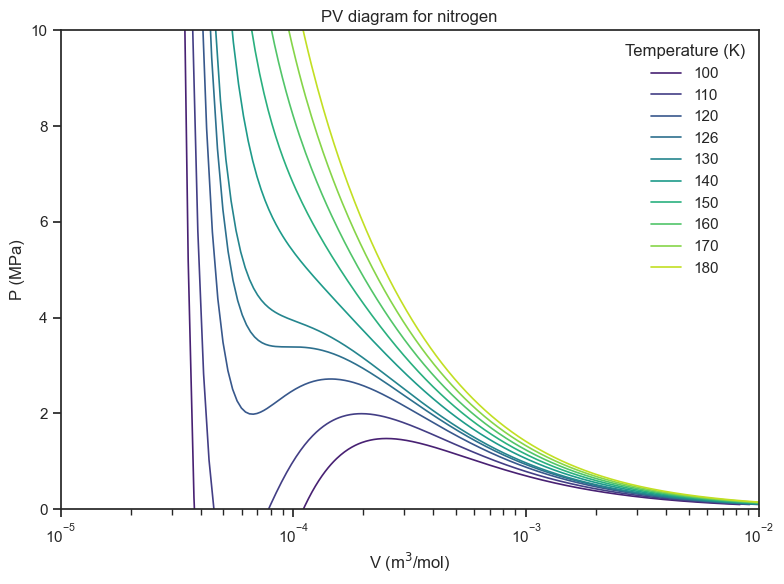

In [4]:
import pandas as pd
import seaborn as sns

temps = sorted(list(range(100, 185, 10)) + [pr.Tc])
rows = []
for T in temps:
    V_max = R*T/(100e3)
    V_min = R*T/(1000e3)*0.03
    V = np.linspace(V_min, V_max, 4000)
    rows.append(pd.DataFrame({"V": V, "P": pr.pressure(V, T)/1e6, "T": f"{T:.0f}"}))
df = pd.concat(rows, ignore_index=True)

sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(data=df, x="V", y="P", hue="T", palette="viridis", linewidth=1.2, ax=ax)
ax.set_xscale("log"); ax.set_ylim([0, 10]); ax.set_xlim([1e-5, 1e-2])
ax.set_xlabel("V (m$^3$/mol)"); ax.set_ylabel("P (MPa)")
ax.set_title("PV diagram for nitrogen")
ax.legend(title="Temperature (K)", frameon=False)
plt.tight_layout(); plt.show()